# Ampère : ce que disent les données

Ce notebook explore les cinq sources d'Ampère avant la simulation du quartier (étape 3). Il suit l'[ADR 030](../docs/decisions/030-notebook-d-exploration.md) et répond à quatre questions :

1. Que couvre chaque source, et avec quels trous ?
2. Que représentent les profils résidentiels d'Enedis ?
3. Comment la consommation des foyers suit-elle la température et le calendrier ?
4. Combien valent les écarts de prix dans une journée, et comment varie l'intensité CO₂ ?

**Période lue** : du 1er juillet 2023 au 30 juin 2025, heure de Paris. La période de test de l'[ADR 007](../docs/decisions/007-periodes-et-protocole-de-test.md), de juillet 2025 à juin 2026, n'est jamais lue : chaque table passe par `ampere.data.periods.scan()`, qui refuse toute plage qui la touche.

**Pour le réexécuter**, depuis la racine du dépôt, une fois les données ingérées :

```bash
uv run --locked --group notebooks jupyter nbconvert --to notebook --execute --inplace \
  --ExecutePreprocessor.record_timing=False --KernelManager.transport_encryption=required \
  notebooks/exploration.ipynb
```

In [1]:
import os
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from ampere.data.days import day_bounds
from ampere.data.folders import data_root
from ampere.data.periods import TEST_FIRST_DAY, TEST_START, scan
from ampere.sources.archive import SINCE

# Jupyter runs a notebook from its own folder; the commands of the project run from the root.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

CLEAN = data_root() / "clean"
# From Paris midnight on 1 July 2023 to the first instant of the test period (ADR 007).
START, END = day_bounds(SINCE)[0], TEST_START
FIRST_DAY, END_DAY = SINCE, TEST_FIRST_DAY

# The palette validated for a light surface with the dataviz skill: blue, orange, aqua.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.6),
        "figure.dpi": 100,
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#b9b8b3",
        "axes.labelcolor": "#52514e",
        "axes.titlesize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "axes.grid": True,
        "grid.color": "#e8e7e3",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "text.color": "#0b0b0b",
        "lines.linewidth": 2,
        "legend.frameon": False,
        "font.size": 10,
    }
)
pl.Config.set_tbl_rows(40)


def fr(value: float, digits: int = 0) -> str:
    """A number as French writes it: 4 268 106 and 41,9."""
    return f"{value:,.{digits}f}".replace(",", "\u202f").replace(".", ",")


def paris(column: str) -> pl.Expr:
    """An instant of the clean layer, stored in UTC, on the clock of Paris."""
    return pl.col(column).dt.convert_time_zone("Europe/Paris")


def season(month: pl.Expr) -> pl.Expr:
    """Winter from December to February, summer from June to August, and the rest in between."""
    return (
        pl.when(month.is_in([12, 1, 2]))
        .then(pl.lit("hiver"))
        .when(month.is_in([6, 7, 8]))
        .then(pl.lit("été"))
        .otherwise(pl.lit("mi-saison"))
    )


last_day = END_DAY - timedelta(days=1)
print(f"Période lue : les jours de Paris du {FIRST_DAY:%d/%m/%Y} au {last_day:%d/%m/%Y},")
print(f"soit de {START:%Y-%m-%d %H:%M} à {END:%Y-%m-%d %H:%M} UTC, fin exclue.")

Période lue : les jours de Paris du 01/07/2023 au 30/06/2025,
soit de 2023-06-30 22:00 à 2025-06-30 22:00 UTC, fin exclue.


## 1. Couverture et qualité

Chaque table est lue sur la période, puis ses valeurs sont comptées face à celles qu'elle devrait avoir. Un jour de Paris compte 96 quarts d'heure, 92 au passage à l'heure d'été et 100 au retour à l'heure d'hiver : la période en compte 70 176, soit 35 088 demi-heures et 17 544 heures.

In [2]:
QUARTERS = (END - START) // timedelta(minutes=15)

prices = scan(CLEAN / "smard" / "prices.parquet", "start", START, END)
measures = scan(CLEAN / "eco2mix" / "measures.parquet", "start", START, END)
weather = scan(CLEAN / "openmeteo" / "weather.parquet", "time", START, END)
consumption = scan(CLEAN / "enedis" / "consumption.parquet", "start", START, END)
days = scan(CLEAN / "calendars" / "days.parquet", "day", FIRST_DAY, END_DAY).collect()
totals = pl.col("power_range").cast(pl.String).str.starts_with("P0")


def coverage(frame: pl.LazyFrame, source: str, keys: list[str], expected: int) -> pl.DataFrame:
    """The values of each series of a table, against those the period should have."""
    return (
        frame.group_by(keys)
        .agg(pl.len().alias("valeurs"))
        .select(
            pl.lit(source).alias("source"),
            pl.concat_str([pl.col(key).cast(pl.String) for key in keys], separator=" · ").alias(
                "série"
            ),
            "valeurs",
            pl.lit(expected).alias("attendues"),
            (pl.lit(expected) - pl.col("valeurs")).alias("manquantes"),
        )
        .collect()
    )


pl.concat(
    [
        coverage(
            prices.with_columns(pl.lit("prix spot").alias("prix")), "SMARD", ["prix"], QUARTERS
        ),
        coverage(measures, "éCO2mix", ["area", "measure"], QUARTERS),
        coverage(
            weather.filter(pl.col("kind") == "observed"), "Open-Meteo", ["variable"], QUARTERS // 4
        ),
        coverage(
            consumption.filter(totals, pl.col("measure") == "mean_w"),
            "Enedis",
            ["profile"],
            QUARTERS // 2,
        ),
    ]
).sort("source", "série")

source,série,valeurs,attendues,manquantes
str,str,u32,i32,u32
"""Enedis""","""RES1 (+ RES1WE)""",35088,35088,0
"""Enedis""","""RES11 (+ RES11WE)""",35088,35088,0
"""Enedis""","""RES2 (+ RES5)""",35088,35088,0
"""Enedis""","""RES2WE""",35088,35088,0
"""Enedis""","""RES3""",35088,35088,0
"""Enedis""","""RES4""",35088,35088,0
"""Open-Meteo""","""diffuse_w_m2""",17544,17544,0
"""Open-Meteo""","""direct_horizontal_w_m2""",17544,17544,0
"""Open-Meteo""","""direct_normal_w_m2""",17544,17544,0


In [3]:
# The version of each value of éCO2mix, and the days the clocks change.
versions = (
    measures.filter(pl.col("measure") == "consumption_mw")
    .group_by("version")
    .agg(
        paris("start").min().dt.date().alias("du"),
        paris("start").max().dt.date().alias("au"),
    )
    .sort("du")
    .collect()
)
changes = (
    prices.group_by(paris("start").dt.date().alias("jour"))
    .agg(pl.len().alias("quarts_d_heure"))
    .filter(pl.col("quarts_d_heure") != 96)
    .sort("jour")
    .collect()
)
print(versions)
print(changes)
holidays, school = days["public_holiday"].count(), days["school_holidays"].count()
print(f"{days.height} jours de calendrier, dont {holidays} fériés et {school} de vacances à Lyon")

shape: (2, 3)
┌──────────────┬────────────┬────────────┐
│ version      ┆ du         ┆ au         │
│ ---          ┆ ---        ┆ ---        │
│ enum         ┆ date       ┆ date       │
╞══════════════╪════════════╪════════════╡
│ definitive   ┆ 2023-07-01 ┆ 2024-12-31 │
│ consolidated ┆ 2025-01-01 ┆ 2025-06-30 │
└──────────────┴────────────┴────────────┘
shape: (4, 2)
┌────────────┬────────────────┐
│ jour       ┆ quarts_d_heure │
│ ---        ┆ ---            │
│ date       ┆ u32            │
╞════════════╪════════════════╡
│ 2023-10-29 ┆ 100            │
│ 2024-03-31 ┆ 92             │
│ 2024-10-27 ┆ 100            │
│ 2025-03-30 ┆ 92             │
└────────────┴────────────────┘
731 jours de calendrier, dont 22 fériés et 252 de vacances à Lyon


Ce que montrent ces comptes :

- **SMARD** : chaque quart d'heure de la période a son prix, y compris les quatre jours de changement d'heure. Jusqu'au 30 septembre 2025, le marché fixait un prix par heure : chaque heure donne ici quatre quarts d'heure au même prix.
- **éCO2mix** : il manque 8 quarts d'heure à chaque mesure. Chaque automne, ODRÉ ne publie qu'une fois l'heure de 2 h, pourtant vécue deux fois au retour de l'heure d'hiver ; le nettoyé laisse ces quarts d'heure vides (ADR 024). Les valeurs sont définitives jusqu'à fin 2024, consolidées ensuite. La consommation, le CO₂ et le solaire sont publiés à la demi-heure, la prévision de RTE au quart d'heure.
- **Open-Meteo** : la météo observée compte toutes ses heures. Les prévisions archivées, elles, ne commencent que le 14 mars 2024 ; c'est pourquoi la mise au point des prévisions commence le 15 mars 2024 (ADR 007).
- **Enedis** : les courbes des six profils, tous foyers confondus, ont leurs 35 088 demi-heures.

## 2. Les profils d'Enedis

Enedis publie la consommation des foyers de la région par **profil** et par **plage de puissance souscrite**. Un profil est la façon type dont une catégorie de clients consomme : Enedis s'en sert pour reconstituer, demi-heure par demi-heure, la consommation des compteurs relevés moins souvent. Le dictionnaire des profils d'Enedis (juillet 2024) et sa note sur ce jeu de données donnent le sens de chacun :

| Segment publié | Profils regroupés | Option tarifaire du foyer |
|---|---|---|
| RES1 (+ RES1WE) | RES1, RES1WE | Base, 6 kVA ou moins ; RES1WE ajoute un tarif du week-end |
| RES11 (+ RES11WE) | RES11, RES11WE | Base, plus de 6 kVA ; RES11WE ajoute un tarif du week-end |
| RES2 (+ RES5) | RES2, RES5 | Heures pleines et heures creuses ; RES5 distingue en plus une saison haute et une saison basse |
| RES2WE | RES2WE | Heures pleines, heures creuses et un tarif du week-end |
| RES3 | RES3 | Une période mobile de 6 h à 22 h et des jours bleus, blancs ou rouges : l'option Tempo |
| RES4 | RES4 | Une pointe mobile de 7 h à 1 h, par zone : l'ancienne option EJP, effacement des jours de pointe |

Pour chaque segment, Enedis publie trois **courbes moyennes**, mesurées par les compteurs communicants : la courbe n° 1 + n° 2 sur tous les foyers, et deux courbes qui les partagent en deux moitiés selon la part de leur consommation entre 8 h et 20 h les jours ouvrés. Le **secret statistique** masque une courbe qui repose sur trop peu de foyers : Enedis la publie alors au pas du jour, ou pas du tout.

In [4]:
segments = (
    consumption.group_by("profile", "power_range")
    .agg(
        pl.col("value").filter(pl.col("measure") == "sites").mean().round(0).alias("foyers"),
        (pl.col("step_minutes").filter(pl.col("measure") == "mean_w") == 30)
        .mean()
        .round(3)
        .alias("part_à_la_demi_heure"),
    )
    .sort("profile", "power_range")
    .collect()
)
profiles = segments.filter(pl.col("power_range").cast(pl.String).str.starts_with("P0"))
complete = segments.filter(pl.col("part_à_la_demi_heure") == 1).height
print(f"{fr(profiles['foyers'].sum())} foyers en moyenne sur la période, en Auvergne-Rhône-Alpes")
print(
    f"{complete} segments sur {segments.height} ont une courbe à la demi-heure sur toute la période"
)
profiles.select(
    "profile",
    "foyers",
    (pl.col("foyers") / pl.col("foyers").sum()).round(3).alias("part_des_foyers"),
)

4 268 106 foyers en moyenne sur la période, en Auvergne-Rhône-Alpes
19 segments sur 39 ont une courbe à la demi-heure sur toute la période


profile,foyers,part_des_foyers
cat,f64,f64
"""RES1 (+ RES1WE)""",1.913519e6,0.448
"""RES11 (+ RES11WE)""",547501.0,0.128
"""RES2 (+ RES5)""",1.610527e6,0.377
"""RES2WE""",27927.0,0.007
"""RES3""",100099.0,0.023
"""RES4""",68533.0,0.016


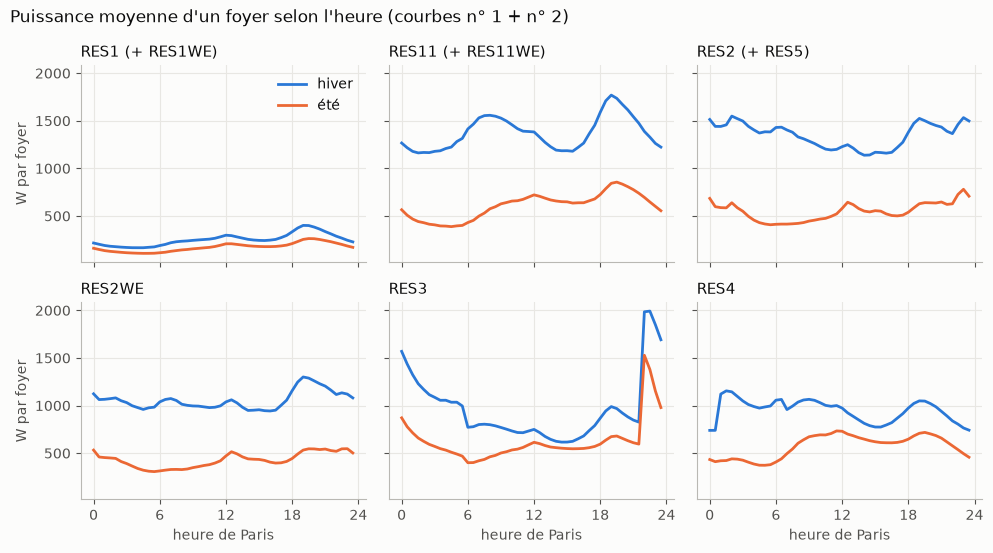

In [5]:
curves = (
    consumption.filter(totals, pl.col("measure") == "mean_w", pl.col("step_minutes") == 30)
    .with_columns(
        season(paris("start").dt.month()).alias("saison"),
        (paris("start").dt.hour() + paris("start").dt.minute() / 60).alias("heure"),
    )
    .filter(pl.col("saison") != "mi-saison")
    .group_by("profile", "saison", "heure")
    .agg(pl.col("value").mean().alias("w"))
    .sort("heure")
    .collect()
)
fig, axes = plt.subplots(2, 3, figsize=(10, 5.6), sharex=True, sharey=True)
for axis, profile in zip(axes.flat, sorted(curves["profile"].unique()), strict=True):
    for name, color in [("hiver", BLUE), ("été", ORANGE)]:
        part = curves.filter(pl.col("profile") == profile, pl.col("saison") == name)
        axis.plot(part["heure"], part["w"], color=color, label=name)
    axis.set_title(profile, loc="left")
    axis.set_xticks([0, 6, 12, 18, 24])
axes[0][0].legend()
for axis in axes[:, 0]:
    axis.set_ylabel("W par foyer")
for axis in axes[-1]:
    axis.set_xlabel("heure de Paris")
fig.suptitle("Puissance moyenne d'un foyer selon l'heure (courbes n° 1 + n° 2)", x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [6]:
# How much more a household consumes in winter than in summer, in each profile.
(
    curves.group_by("profile", "saison")
    .agg(pl.col("w").mean())
    .pivot(on="saison", index="profile", values="w")
    .with_columns((pl.col("hiver") / pl.col("été")).round(2).alias("hiver_sur_été"))
    .sort("profile")
)

profile,hiver,été,hiver_sur_été
cat,f64,f64,f64
"""RES1 (+ RES1WE)""",253.165055,172.646966,1.47
"""RES11 (+ RES11WE)""",1372.333103,606.639946,2.26
"""RES2 (+ RES5)""",1350.93186,547.039402,2.47
"""RES2WE""",1056.875921,428.787591,2.46
"""RES3""",961.64756,627.096694,1.53
"""RES4""",949.572514,571.86481,1.66


In [7]:
# Which half of the households does each curve hold? Their share of energy from 8:00 to 20:00 on
# weekdays says it.
daytime = (paris("start").dt.weekday() <= 5) & paris("start").dt.hour().is_between(8, 19)
(
    consumption.filter(
        totals, pl.col("measure").is_in(["mean_1_w", "mean_2_w"]), pl.col("step_minutes") == 30
    )
    .group_by("profile", "measure")
    .agg((pl.col("value").filter(daytime).sum() / pl.col("value").sum()).round(3).alias("part"))
    .collect()
    .pivot(on="measure", index="profile", values="part")
    .sort("profile")
)

profile,mean_1_w,mean_2_w
cat,f64,f64
"""RES1 (+ RES1WE)""",0.325,0.437
"""RES11 (+ RES11WE)""",0.316,0.417
"""RES2 (+ RES5)""",0.264,0.381
"""RES2WE""",0.262,0.387
"""RES3""",0.2,0.357
"""RES4""",0.304,0.436


Ce que disent les profils :

- **La base domine** : les foyers au tarif base (RES1 et RES11) sont 58 % de la région, ceux en heures pleines et creuses (RES2) 38 %. Tempo et l'EJP ne comptent que 2,3 % et 1,6 % des foyers.
- **Le secret statistique** ne laisse une courbe complète à la demi-heure qu'à 19 segments sur 39. Les autres ne sont publiés à la demi-heure que la semaine, ou le jour, du pic de consommation de chaque mois, et au pas du jour le reste du temps ; RES4 de 0 à 9 kVA, 273 foyers, ne l'est jamais. La simulation tirera donc ses foyers parmi les segments complets, ou dans les courbes de chaque profil, toutes puissances confondues.
- **Le chauffage électrique se voit l'hiver** : un foyer RES11, RES2 ou RES2WE consomme alors 2,3 à 2,5 fois plus qu'en été, avec une pointe vers 19 h. Chez Tempo et l'EJP, le rapport n'est que de 1,5 et 1,7 : leurs foyers consomment déjà beaucoup l'été, ceux de Tempo plus que tout autre profil. Les petits foyers de RES1, au tarif base de 6 kVA ou moins, restent sous 400 W toute l'année.
- **Les heures creuses aussi** : chez Tempo (RES3), la consommation fait un bond à 22 h, quand ses heures creuses commencent et que les chauffe-eau se mettent en route ; chez l'EJP (RES4), le saut vient à 1 h, quand commencent les siennes. En heures pleines et creuses (RES2), la hausse du soir est plus douce : Enedis fixe les heures creuses localement, et elles varient d'un foyer à l'autre.
- **Les courbes n° 1 et n° 2** : pour les six profils, la courbe n° 2 porte la plus grande part de consommation en journée, par exemple 44 % contre 33 % pour RES1. Elle rassemble donc les foyers qui consomment le plus entre 8 h et 20 h. La note d'Enedis le dit en page 7, alors que son tableau de la page 4 inverse les deux courbes.

## 3. La consommation et la météo

Les jours qu'Enedis n'a pas encore publiés, dont hier, le jumeau estimera la consommation à partir de la température et du calendrier (conception, section 5.2). Cette partie regarde si c'est raisonnable.

La consommation d'un foyer est ici la moyenne mesurée des courbes n° 1 + n° 2, pondérée par le nombre de foyers de chaque profil. L'énergie totale d'Enedis ne sert pas : pour la plupart des foyers, Enedis la reconstitue avec un profil ajusté à la température, et elle suivrait la température en partie par construction.

In [8]:
day = paris("start").dt.date().alias("day")
households = (
    consumption.filter(totals, pl.col("measure").is_in(["mean_w", "sites"]))
    .group_by(day, "profile")
    .agg(
        pl.col("value").filter(pl.col("measure") == "mean_w").mean().alias("mean_w"),
        pl.col("value").filter(pl.col("measure") == "sites").mean().alias("sites"),
    )
    .group_by("day")
    .agg(((pl.col("mean_w") * pl.col("sites")).sum() / pl.col("sites").sum()).alias("foyer_w"))
)
temperature = (
    weather.filter(pl.col("kind") == "observed", pl.col("variable") == "temperature_c")
    .group_by(paris("time").dt.date().alias("day"))
    .agg(pl.col("value").mean().alias("température_c"))
)
national = (
    measures.filter(pl.col("area") == "FR", pl.col("measure") == "consumption_mw")
    .group_by(day)
    .agg(pl.col("value").mean().alias("national_mw"))
)
daily = (
    households.join(temperature, on="day")
    .join(national, on="day")
    .join(days.lazy().select("day", "public_holiday", "school_holidays"), on="day")
    .sort("day")
    .collect()
)
daily.select("foyer_w", "température_c", "national_mw").describe()

statistic,foyer_w,température_c,national_mw
str,f64,f64,f64
"""count""",731.0,731.0,731.0
"""null_count""",0.0,0.0,0.0
"""mean""",559.372773,13.446184,50076.793245
"""std""",206.268628,7.536315,9255.225797
"""min""",353.088223,-2.758333,35863.958333
"""25%""",389.275113,7.5625,43680.395833
"""50%""",452.952705,13.2875,46793.583333
"""75%""",713.886187,18.9375,57200.604167
"""max""",1164.503225,30.304167,78167.5625


Seuil : 15,0 °C
Au-dessus du seuil : 392 W par foyer ; en dessous, 41,9 W de plus par degré
Part des écarts d'un jour à l'autre expliquée (R²) : 0,93
Erreur absolue moyenne : 39 W


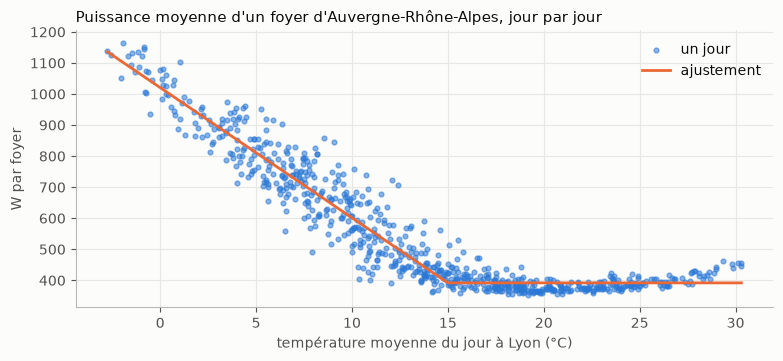

In [9]:
t = daily["température_c"].to_numpy()
y = daily["foyer_w"].to_numpy()


def hinge(threshold: float) -> tuple[np.ndarray, np.ndarray]:
    """The least-squares fit of y = a + b * max(0, threshold - t), and its residuals."""
    x = np.column_stack([np.ones_like(t), np.maximum(0.0, threshold - t)])
    coefficients, *_ = np.linalg.lstsq(x, y, rcond=None)
    return coefficients, y - x @ coefficients


# The threshold that leaves the smallest residuals, every half degree from 10 to 22 °C.
threshold = min(np.arange(10.0, 22.01, 0.5), key=lambda value: hinge(value)[1].var())
(base, slope), residuals = hinge(threshold)
print(f"Seuil : {fr(threshold, 1)} °C")
print(
    f"Au-dessus du seuil : {fr(base)} W par foyer ; en dessous, {fr(slope, 1)} W de plus par degré"
)
print(
    f"Part des écarts d'un jour à l'autre expliquée (R²) : {fr(1 - residuals.var() / y.var(), 2)}"
)
print(f"Erreur absolue moyenne : {fr(np.abs(residuals).mean())} W")

fig, axis = plt.subplots()
axis.scatter(t, y, s=12, color=BLUE, alpha=0.55, label="un jour")
grid = np.linspace(t.min(), t.max(), 200)
axis.plot(grid, base + slope * np.maximum(0.0, threshold - grid), color=ORANGE, label="ajustement")
axis.set_xlabel("température moyenne du jour à Lyon (°C)")
axis.set_ylabel("W par foyer")
axis.set_title("Puissance moyenne d'un foyer d'Auvergne-Rhône-Alpes, jour par jour", loc="left")
axis.legend()
plt.show()

In [10]:
# What the temperature leaves: the mean gap of each kind of day to the fit.
kind = (
    pl.when(pl.col("public_holiday").is_not_null())
    .then(pl.lit("jour férié"))
    .when(pl.col("day").dt.weekday() == 7)
    .then(pl.lit("dimanche"))
    .when(pl.col("day").dt.weekday() == 6)
    .then(pl.lit("samedi"))
    .when(pl.col("school_holidays").is_not_null())
    .then(pl.lit("vacances, en semaine"))
    .otherwise(pl.lit("semaine"))
)
(
    daily.with_columns(pl.Series("écart_w", residuals), kind.alias("jour"))
    .group_by("jour")
    .agg(pl.len().alias("jours"), pl.col("écart_w").mean().round(1))
    .sort("écart_w")
)

jour,jours,écart_w
str,u32,f64
"""vacances, en semaine""",151,-11.3
"""semaine""",350,-7.2
"""jour férié""",22,7.4
"""samedi""",104,11.1
"""dimanche""",104,27.9


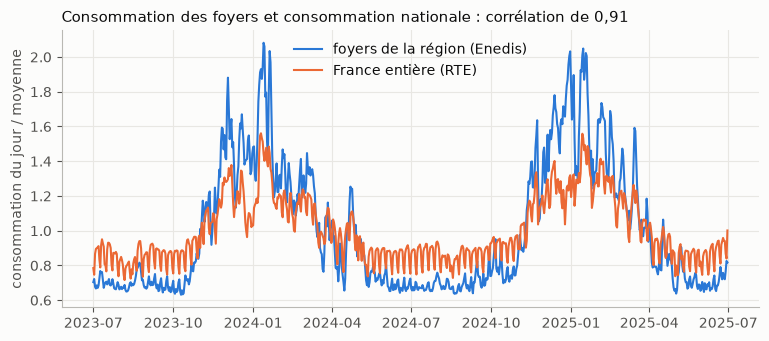

In [11]:
r = daily.select(pl.corr("foyer_w", "national_mw")).item()
fig, axis = plt.subplots()
for column, name, color in [
    ("foyer_w", "foyers de la région (Enedis)", BLUE),
    ("national_mw", "France entière (RTE)", ORANGE),
]:
    axis.plot(
        daily["day"], daily[column] / daily[column].mean(), color=color, label=name, linewidth=1.5
    )
axis.set_ylabel("consommation du jour / moyenne")
axis.set_title(
    f"Consommation des foyers et consommation nationale : corrélation de {fr(r, 2)}", loc="left"
)
axis.legend()
plt.show()

Ce que montrent la température et le calendrier :

- **Un seuil de chauffage vers 15 °C** : au-dessus, un foyer consomme en moyenne autour de 390 W, soit 9,4 kWh par jour ; en dessous, chaque degré de moins ajoute environ 42 W, 1 kWh par jour. Cette seule droite brisée explique 93 % des écarts d'un jour à l'autre, avec une erreur moyenne de 39 W.
- **Le calendrier ajoute un effet net, mais petit**, une fois la température connue : un dimanche, un foyer consomme 28 W de plus que ne le dit la droite, un samedi 11 W de plus ; un jour de semaine, 7 W de moins, et un jour de vacances en semaine 11 W de moins.
- **La consommation nationale suit celle des foyers** (corrélation de 0,91), avec des variations moins fortes : les jours les plus froids, les foyers de la région consomment jusqu'à deux fois leur moyenne, la France entière une fois et demie, car l'industrie et les bureaux dépendent moins de la température. RTE publie la sienne dès le lendemain, Enedis un trimestre plus tard : c'est une piste pour estimer les jours récents, à comparer à la température seule à l'étape 3.

## 4. Les prix et le CO₂

Sur la période, le prix spot est fixé heure par heure, la veille vers 13 h. Une batterie gagne à se charger aux heures les moins chères pour se décharger aux plus chères : l'écart entre les deux fait son gain. Les prix du lendemain étant connus la veille, le pilotage n'a pas à les prévoir.

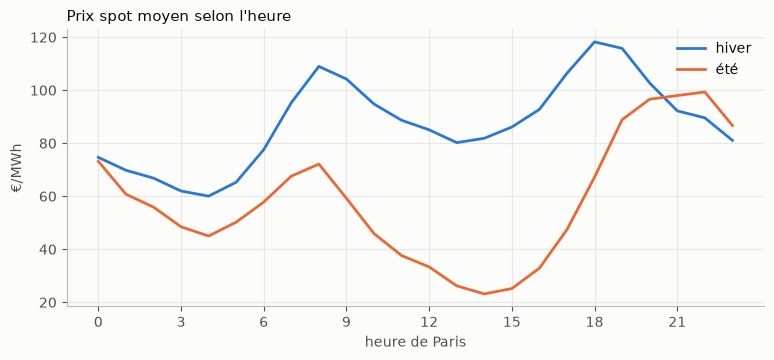

In [12]:
hourly = (
    prices.group_by(paris("start").dt.truncate("1h").alias("hour"))
    .agg(pl.col("price_eur_per_mwh").mean().alias("prix"))
    .collect()
)


def by_hour(frame: pl.DataFrame, column: str) -> pl.DataFrame:
    """The mean of a column by hour of Paris, in winter and in summer."""
    return (
        frame.with_columns(
            season(pl.col("hour").dt.month()).alias("saison"),
            pl.col("hour").dt.hour().alias("heure"),
        )
        .filter(pl.col("saison") != "mi-saison")
        .group_by("saison", "heure")
        .agg(pl.col(column).mean())
        .sort("heure")
    )


shape = by_hour(hourly, "prix")
fig, axis = plt.subplots()
for name, color in [("hiver", BLUE), ("été", ORANGE)]:
    part = shape.filter(pl.col("saison") == name)
    axis.plot(part["heure"], part["prix"], color=color, label=name)
axis.set_xticks(range(0, 24, 3))
axis.set_xlabel("heure de Paris")
axis.set_ylabel("€/MWh")
axis.set_title("Prix spot moyen selon l'heure", loc="left")
axis.legend()
plt.show()

Écart médian entre les 4 heures les plus chères et les 4 moins chères : 64 €/MWh ; un jour sur dix, plus de 109 €/MWh


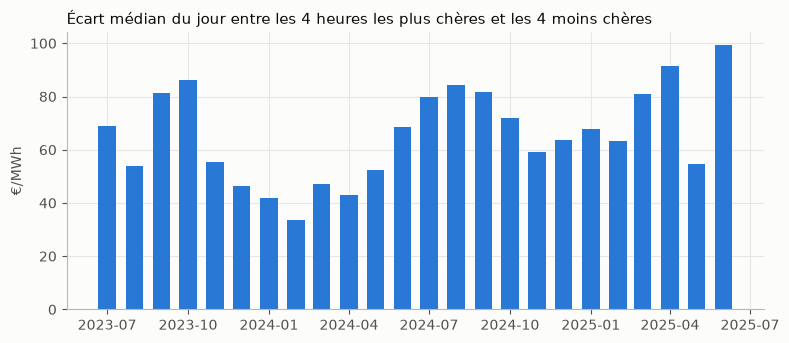

In [13]:
spread = hourly.group_by(pl.col("hour").dt.date().alias("day")).agg(
    (pl.col("prix").top_k(4).mean() - pl.col("prix").bottom_k(4).mean()).alias("écart")
)
print(
    f"Écart médian entre les 4 heures les plus chères et les 4 moins chères : "
    f"{fr(spread['écart'].median())} €/MWh ; un jour sur dix, plus de "
    f"{fr(spread['écart'].quantile(0.9))} €/MWh"
)
monthly = (
    spread.group_by(pl.col("day").dt.truncate("1mo").alias("mois"))
    .agg(pl.col("écart").median())
    .sort("mois")
)
fig, axis = plt.subplots()
axis.bar(monthly["mois"], monthly["écart"], width=20, color=BLUE)
axis.set_ylabel("€/MWh")
axis.set_title(
    "Écart médian du jour entre les 4 heures les plus chères et les 4 moins chères", loc="left"
)
plt.show()

809 heures à prix négatif sur 17 544


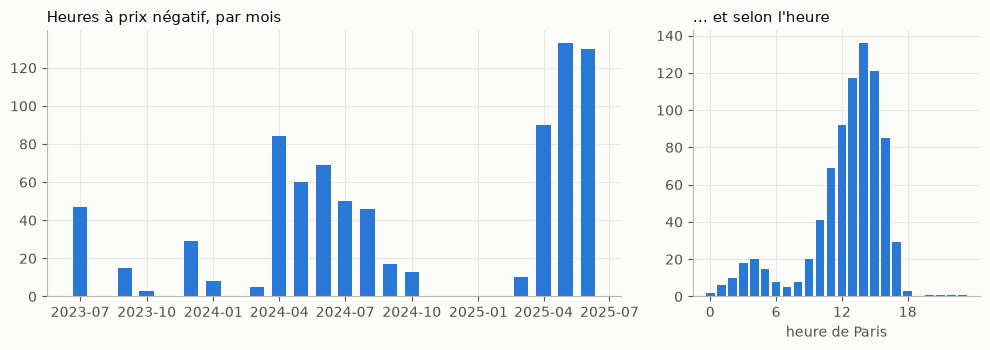

In [14]:
negative = hourly.filter(pl.col("prix") < 0)
print(f"{fr(negative.height)} heures à prix négatif sur {fr(hourly.height)}")
by_month = negative.group_by(pl.col("hour").dt.truncate("1mo").alias("mois")).len().sort("mois")
by_clock = negative.group_by(pl.col("hour").dt.hour().alias("heure")).len().sort("heure")
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.6), width_ratios=[2, 1])
left.bar(by_month["mois"], by_month["len"], width=20, color=BLUE)
left.set_title("Heures à prix négatif, par mois", loc="left")
right.bar(by_clock["heure"], by_clock["len"], color=BLUE)
right.set_xticks(range(0, 24, 6))
right.set_xlabel("heure de Paris")
right.set_title("… et selon l'heure", loc="left")
fig.tight_layout()
plt.show()

Intensité moyenne : 20 g/kWh, de 6 à 70
Corrélation heure par heure entre le prix et l'intensité CO₂ : 0,65


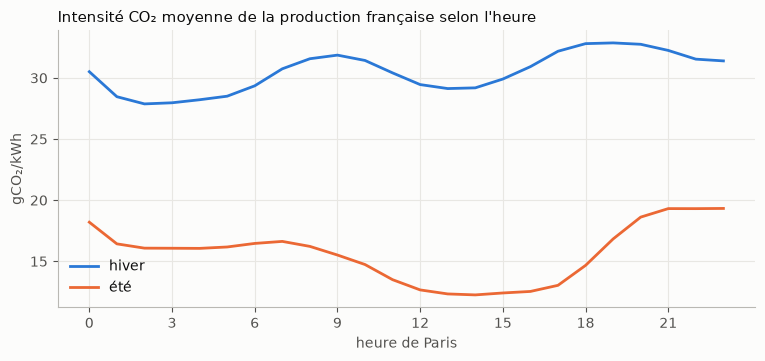

In [15]:
co2 = (
    measures.filter(pl.col("area") == "FR", pl.col("measure") == "co2_g_per_kwh")
    .group_by(paris("start").dt.truncate("1h").alias("hour"))
    .agg(pl.col("value").mean().alias("co2"))
    .collect()
)
r = hourly.join(co2, on="hour").select(pl.corr("prix", "co2")).item()
low, high, mean = co2["co2"].min(), co2["co2"].max(), co2["co2"].mean()
print(f"Intensité moyenne : {fr(mean)} g/kWh, de {fr(low)} à {fr(high)}")
print(f"Corrélation heure par heure entre le prix et l'intensité CO₂ : {fr(r, 2)}")
shape = by_hour(co2, "co2")
fig, axis = plt.subplots()
for name, color in [("hiver", BLUE), ("été", ORANGE)]:
    part = shape.filter(pl.col("saison") == name)
    axis.plot(part["heure"], part["co2"], color=color, label=name)
axis.set_xticks(range(0, 24, 3))
axis.set_xlabel("heure de Paris")
axis.set_ylabel("gCO₂/kWh")
axis.set_title("Intensité CO₂ moyenne de la production française selon l'heure", loc="left")
axis.legend()
plt.show()

Ce que montrent les prix et le CO₂ :

- **La forme d'une journée** : l'hiver, le prix a deux pointes, vers 8 h et vers 19 h, et descend la nuit. L'été, il plonge en milieu de journée, jusqu'à 23 €/MWh en moyenne à 14 h, quand le solaire produit, puis remonte jusqu'à 22 h.
- **L'écart du jour** entre les 4 heures les plus chères et les 4 moins chères vaut 64 €/MWh en médiane, et plus de 109 €/MWh un jour sur dix. Il est souvent plus grand de juin à octobre qu'en hiver. Une batterie qui déplacerait 10 kWh par jour gagnerait, sur les prix seuls, de l'ordre de 0,64 € par jour, 230 € par an. Ce n'est qu'un ordre de grandeur : les pertes de la batterie et les taxes payées sur chaque kWh acheté en plus le réduisent, un second cycle les jours à deux pointes l'augmente, et l'étape 4 mesurera le vrai gain.
- **Les prix négatifs** : 809 heures sur deux ans, surtout d'avril à juin et entre 11 h et 16 h, quand le solaire déborde. Ce sont les heures où charger une batterie coûte le moins ; un foyer y paie encore l'acheminement et les taxes de chaque kWh.
- **Le CO₂** : 20 g/kWh en moyenne, deux fois plus l'hiver que l'été. Il suit le prix (corrélation de 0,65) : les heures chères sont aussi celles où les centrales au gaz tournent. Minimiser la facture devrait donc aussi baisser les émissions ; l'étape 4 le mesurera (ADR 008).

## Ce que cela change pour la suite

- **Étape 3, la simulation** : les foyers seront tirés parmi les segments d'Enedis complets à la demi-heure, selon leur nombre de foyers. Pour les jours récents, un modèle de la température et du calendrier explique déjà 93 % des écarts ; la consommation nationale de RTE est une piste de plus.
- **Étape 4, le pilotage** : l'écart de prix du jour donne l'ordre de grandeur du gain d'une batterie, et les heures à prix négatif, celles où la charger. Le CO₂ suit le prix : on vérifiera que la facture la plus basse émet aussi moins.
- **Étape 5, les prévisions** : le seuil de 15 °C et l'effet du calendrier deviennent des variables du modèle.

## Sources

Ampère a transformé ces données : les tableaux et les figures en sont des comptes, des moyennes, des écarts et des ajustements. Les dates de mise à jour ont été relevées le 28 septembre 2026, jour de l'exécution.

- Prix spot : Bundesnetzagentur | SMARD.de, sous licence [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
- Consommation nationale, prévision de RTE et intensité CO₂ : RTE, éCO2mix, par ODRÉ, jeux consolidés et définitifs, sous [Licence Ouverte 2.0](https://www.etalab.gouv.fr/licence-ouverte-open-licence/), mise à jour du 28 septembre 2026.
- Météo : [Weather data by Open-Meteo.com](https://open-meteo.com/), sous licence [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
- Consommation des foyers : Enedis, open data, agrégats de consommation au pas d'une demi-heure, sous Licence Ouverte 2.0, mise à jour du 30 juillet 2026 ; le dictionnaire des profils (jeu « Coefficients des profils », juillet 2024) et la note « Dictionnaire de données, agrégats segmentés au pas ½ h », version 3.
- Calendriers : Éducation nationale, calendrier scolaire, mis à jour le 18 septembre 2026, et Etalab, jours fériés, mis à jour le 2 janvier 2026, sous Licence Ouverte 2.0.